In [200]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [201]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML-LastSem/Week5/FruitinAmazon.zip"
extract_to = ""

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [202]:
!ls FruitinAmazon/train

acai  cupuacu  graviola  guarana  pupunha  tucuma


In [203]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from sklearn.metrics import accuracy_score, classification_report

BASE_DIR = "FruitinAmazon"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 6

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [204]:
classes = sorted(os.listdir(TRAIN_DIR))
{c: i for i, c in enumerate(classes)}

{'acai': 0,
 'cupuacu': 1,
 'graviola': 2,
 'guarana': 3,
 'pupunha': 4,
 'tucuma': 5}

In [205]:
class MyDataset(Dataset):
    def __init__(self, dir_path, is_train=False):
        self.dir_path = dir_path
        self.is_train = is_train
        self.classes = sorted(os.listdir(dir_path))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []
        for c in self.classes:
            class_folder = os.path.join(dir_path, c)
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                self.samples.append((img_path, self.class_to_idx[c]))

        self.train_transform = transforms.Compose([
            transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.is_train:
            img = self.train_transform(img)
        else:
            img = self.val_transform(img)
        return img, label

In [206]:
# full train set, then split 80/20 into train and val
full_train_dataset = MyDataset(TRAIN_DIR, is_train=True)
test_dataset = MyDataset(TEST_DIR, is_train=False)

val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

len(train_dataset), len(val_dataset), len(test_dataset)

(72, 18, 30)

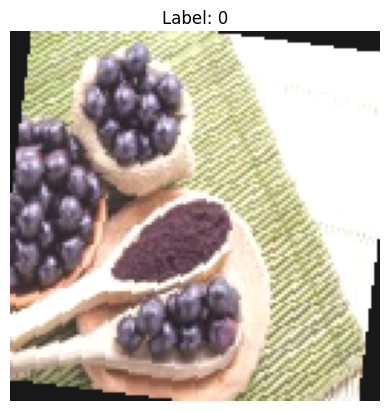

In [207]:
image, label = train_dataset[1]
# Convert (C, H, W) -> (H, W, C)
image_to_show = image.permute(1, 2, 0)
plt.imshow(image_to_show)
plt.title(f"Label: {label}")
plt.axis('off') # Hide pixel coordinates
plt.show()

In [208]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [209]:
class MyCNN(nn.Module):
    def __init__(self, input_channels):
        super().__init__()

        self.base = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.base(x)
        x = self.head(x)
        return x

In [210]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [211]:
learning_rate = 0.0003
epochs = 30

model = MyCNN(3)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

early_stopper = EarlyStopping(patience=7, min_delta=0.001)

In [212]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')
checkpoint_path = 'best_model.pth'

for epoch in range(epochs):

    # train
    model.train()
    total_train_loss, train_correct, train_total = 0, 0, 0

    for batch_features, batch_labels in train_loader:

        # move data to device (gpu)
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_train_loss = total_train_loss + loss.item()
        train_correct = train_correct + (outputs.argmax(dim=1) == batch_labels).sum().item()
        train_total = train_total + batch_labels.size(0)

    avg_loss = total_train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # val
    model.eval()
    total_epoch_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_features, batch_labels in val_loader:

            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            total_epoch_val_loss = total_epoch_val_loss + loss.item()
            preds = outputs.argmax(dim=1)
            correct = correct + (preds == batch_labels).sum().item()
            total = total + batch_labels.size(0)

    avg_val_loss = total_epoch_val_loss / len(val_loader)

    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save(model.state_dict(), checkpoint_path)
      print(f"------Best model saved at epoch {epoch+1}-------")

    val_acc = correct / total

    train_losses.append(avg_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch: {epoch + 1} , Loss: {avg_loss:.4f} , Train Acc: {train_acc:.4f} , Val Loss: {avg_val_loss:.4f} , Val Acc: {val_acc:.4f}')

    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered. Training halted.")
        break

------Best model saved at epoch 1-------
Epoch: 1 , Loss: 1.8082 , Train Acc: 0.1111 , Val Loss: 1.7874 , Val Acc: 0.1667
Epoch: 2 , Loss: 1.7885 , Train Acc: 0.1389 , Val Loss: 1.8021 , Val Acc: 0.2778
Epoch: 3 , Loss: 1.7885 , Train Acc: 0.1667 , Val Loss: 1.8032 , Val Acc: 0.2222
Epoch: 4 , Loss: 1.7849 , Train Acc: 0.2500 , Val Loss: 1.8208 , Val Acc: 0.1667
Epoch: 5 , Loss: 1.7757 , Train Acc: 0.1944 , Val Loss: 1.8187 , Val Acc: 0.1667
Epoch: 6 , Loss: 1.7535 , Train Acc: 0.1806 , Val Loss: 1.8195 , Val Acc: 0.1667
Epoch: 7 , Loss: 1.7522 , Train Acc: 0.2361 , Val Loss: 1.8403 , Val Acc: 0.2222
------Best model saved at epoch 8-------
Epoch: 8 , Loss: 1.7371 , Train Acc: 0.2361 , Val Loss: 1.7692 , Val Acc: 0.2778
------Best model saved at epoch 9-------
Epoch: 9 , Loss: 1.7102 , Train Acc: 0.2917 , Val Loss: 1.7066 , Val Acc: 0.2778
Epoch: 10 , Loss: 1.6603 , Train Acc: 0.2917 , Val Loss: 1.7349 , Val Acc: 0.2778
------Best model saved at epoch 11-------
Epoch: 11 , Loss: 1.6044

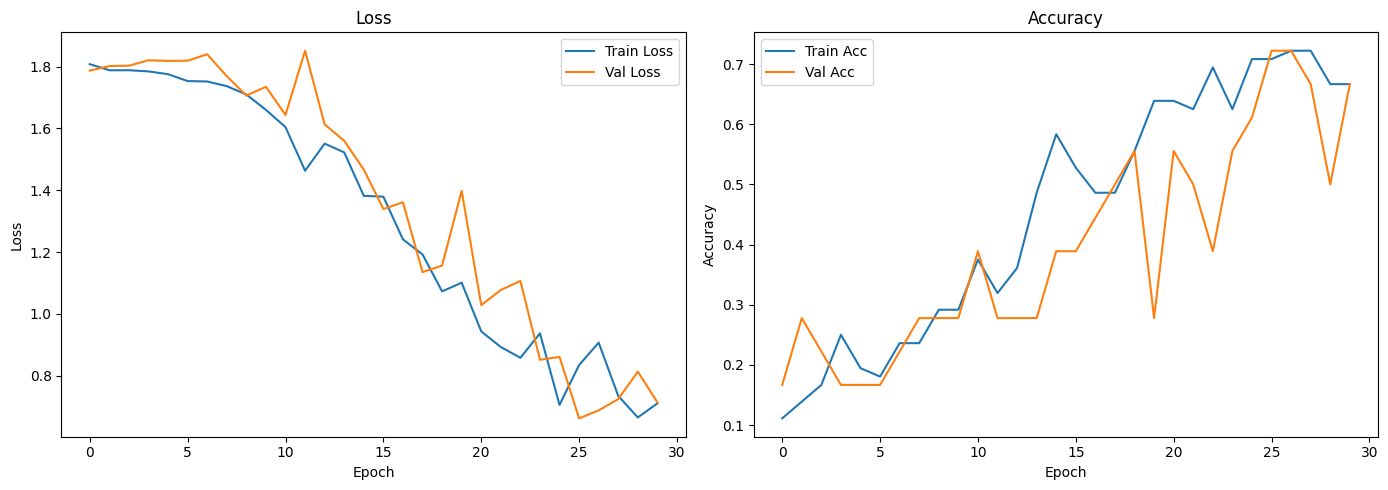

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs, label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [214]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

print(f'Test Accuracy: {accuracy_score(all_labels, all_preds):}')

Test Accuracy: 0.7


In [215]:
print(classification_report(all_labels, all_preds, target_names=full_train_dataset.classes))

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.60      0.60      0.60         5
    graviola       1.00      0.80      0.89         5
     guarana       0.62      1.00      0.77         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.70        30
   macro avg       0.76      0.70      0.67        30
weighted avg       0.76      0.70      0.67        30

